# Hugging Face NLP Pipeline: Question Answering, Sentiment Analysis, Code Autocompletion

In [1]:
%pip install transformers

   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.4 MB 5.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/10.4 MB 12.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.8/10.4 MB 13.5 MB/s eta 0:00:01
   ------------------------------------- -- 9.7/10.4 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 10.4/10.4 MB 13.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 13.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## Почему трансформеры?

- Не простые эмбеддинги, а позиционные (часть слова + положение в последовательности)
- 10-20 одинаковых модулей, которые постоянно рассылают друг другу "запросы"
- Каждый модуль практически равен строчке кода в программе (хотя может делать гораздо более сложные вещи)
- Очень эффективно вычисляется и распараллеливается

В предшествующих (реккурентных) сетях обучение и вычисление велось по цепочке. Тут все параллельно.

* GPT3 учитывал 8000.
* GPT4 учитывает 32000 токенов в качестве контекста (объем маленькой книги).
* Flash attention – 64000 (среднего размера книга)

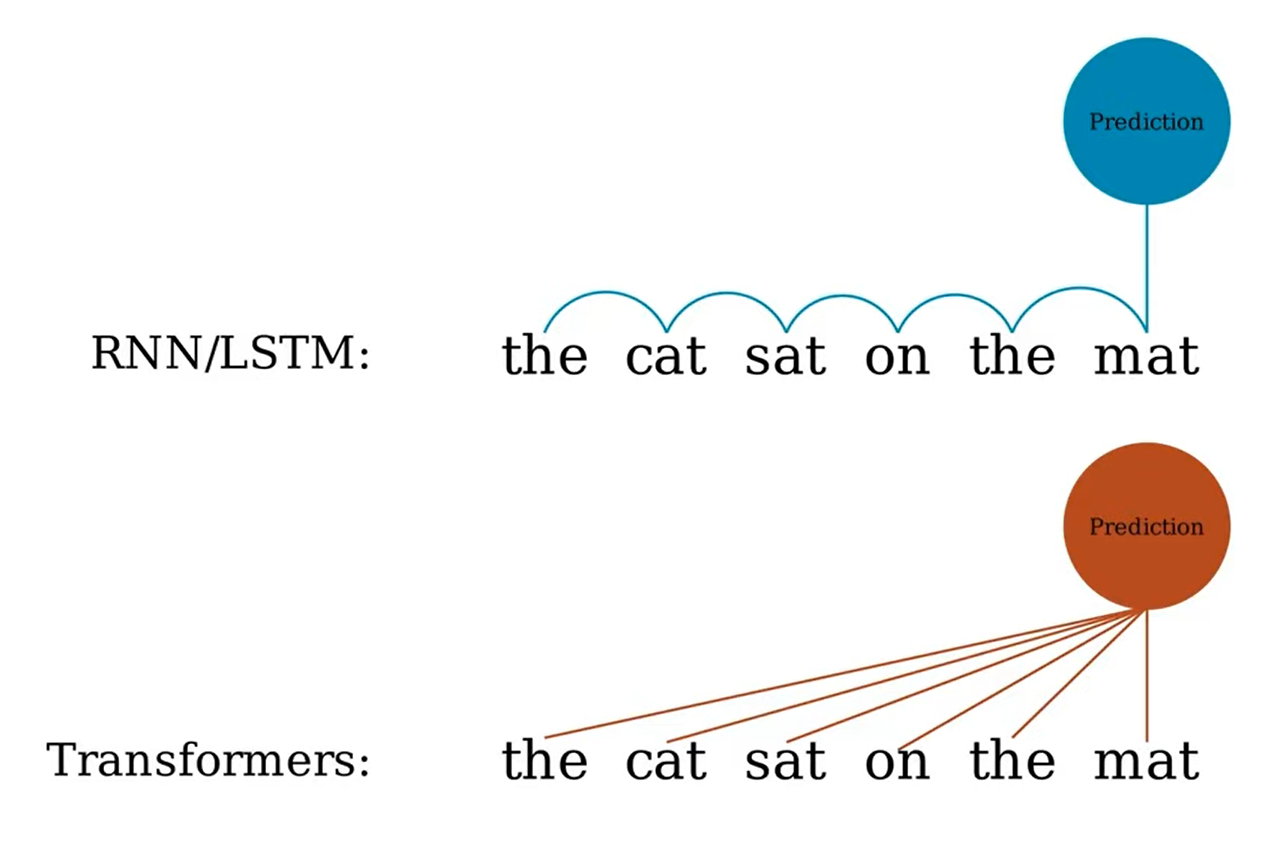

https://www.youtube.com/watch?v=NzLwHcqE6Jw

Зато... трансформеры требуют огромного количества памяти.

* _Stable Diffusion_ – модели от 10 Гб и больше
* _GPT_... давайте посмотрим на сайте

# Что такое Huggingface

* Сотни тысяч предобученных моделей
* Очень много датасетов (как и в kaggle, и в Google Dataset Search)
* HF Spaces

Пройдемся по https://huggingface.co/

Когда нужно хранить модель локально, а когда лучше пользоваться API?

## Примеры кода (pipeline)

Объекты Pipeline: https://huggingface.co/docs/transformers/v4.35.2/en/main_classes/pipelines

Демо чат-бота:

- https://huggingface.co/tasks/conversational
- https://huggingface.co/docs/transformers/v4.35.2/en/main_classes/pipelines#transformers.ConversationalPipeline

```python
from transformers import pipeline, Conversation

chatbot = pipeline(model="microsoft/DialoGPT-medium")
conversation = Conversation("Going to the movies tonight - any suggestions?")
conversation = chatbot(conversation)
conversation.generated_responses[-1]
>>> 'The Big Lebowski'

conversation.add_user_input("Is it an action movie?")
conversation = chatbot(conversation)
conversation.generated_responses[-1]
>>> "It's a comedy."
```

Онлайн-демо: https://huggingface.co/spaces/shawhin/vanilla-chatbot

# Задачи компьютерного зрения

* Оценка карты глубины по фотографии: https://huggingface.co/blog/cv_state#support-for-pipelines
* Классификация изображений
* Сегментация изображений
* Перевод изображения в изображение
* Детекция объектов
* Классификация видео
* Классификация без заранее определенных меток (ZeroShot Classification)

Перечень задач: https://huggingface.co/docs/transformers/main/en/main_classes/pipelines#computer-vision

In [1]:
import torch
print(torch.__version__)

2.6.0+cpu


In [2]:
from transformers import pipeline

depth_estimator = pipeline(task="depth-estimation") # model="Intel/dpt-large"
output = depth_estimator("https://upload.wikimedia.org/wikipedia/commons/thumb/0/05/%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D0%B0._%D0%9A%D1%80%D0%B5%D0%BC%D0%BB%D1%8C._%D0%9A%D0%BE%D0%BB%D0%BE%D0%BA%D0%BE%D0%BB%D1%8C%D0%BD%D1%8F_%D0%98%D0%B2%D0%B0%D0%BD%D0%B0_%D0%92%D0%B5%D0%BB%D0%B8%D0%BA%D0%BE%D0%B3%D0%BE_IMG_2111.2_e1b2sm_VIII-2009.jpg/1280px-%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D0%B0._%D0%9A%D1%80%D0%B5%D0%BC%D0%BB%D1%8C._%D0%9A%D0%BE%D0%BB%D0%BE%D0%BA%D0%BE%D0%BB%D1%8C%D0%BD%D1%8F_%D0%98%D0%B2%D0%B0%D0%BD%D0%B0_%D0%92%D0%B5%D0%BB%D0%B8%D0%BA%D0%BE%D0%B3%D0%BE_IMG_2111.2_e1b2sm_VIII-2009.jpg")

# Вызов этой команды возвращает нам тензор, в котором дана оценочная информация
# об удаленности каждого объекта от зрителя (в метрах)
output["depth"]

No model was supplied, defaulted to Intel/dpt-large and revision bc15f29 (https://huggingface.co/Intel/dpt-large).
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x00000211CEDA35B0>

Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


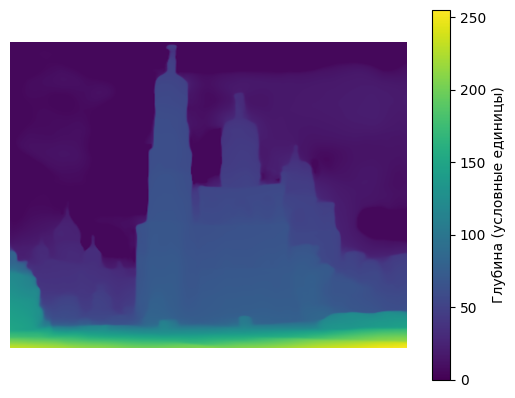

In [ ]:
from transformers import pipeline
import matplotlib.pyplot as plt

# Инициализация pipeline 
depth_estimator = pipeline(
    task="depth-estimation",
    model="Intel/dpt-large",
    device="cuda:0" if torch.cuda.is_available() else "cpu"
)

# Обработка изображения
img_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/0/05/%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D0%B0._%D0%9A%D1%80%D0%B5%D0%BC%D0%BB%D1%8C._%D0%9A%D0%BE%D0%BB%D0%BE%D0%BA%D0%BE%D0%BB%D1%8C%D0%BD%D1%8F_%D0%98%D0%B2%D0%B0%D0%BD%D0%B0_%D0%92%D0%B5%D0%BB%D0%B8%D0%BA%D0%BE%D0%B3%D0%BE_IMG_2111.2_e1b2sm_VIII-2009.jpg/1280px-%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D0%B0._%D0%9A%D1%80%D0%B5%D0%BC%D0%BB%D1%8C._%D0%9A%D0%BE%D0%BB%D0%BE%D0%BA%D0%BE%D0%BB%D1%8C%D0%BD%D1%8F_%D0%98%D0%B2%D0%B0%D0%BD%D0%B0_%D0%92%D0%B5%D0%BB%D0%B8%D0%BA%D0%BE%D0%B3%D0%BE_IMG_2111.2_e1b2sm_VIII-2009.jpg"
output = depth_estimator(img_url)

# Визуализация
plt.imshow(output["depth"], cmap="viridis")
plt.colorbar(label="Глубина (условные единицы)")
plt.axis("off")
plt.show()

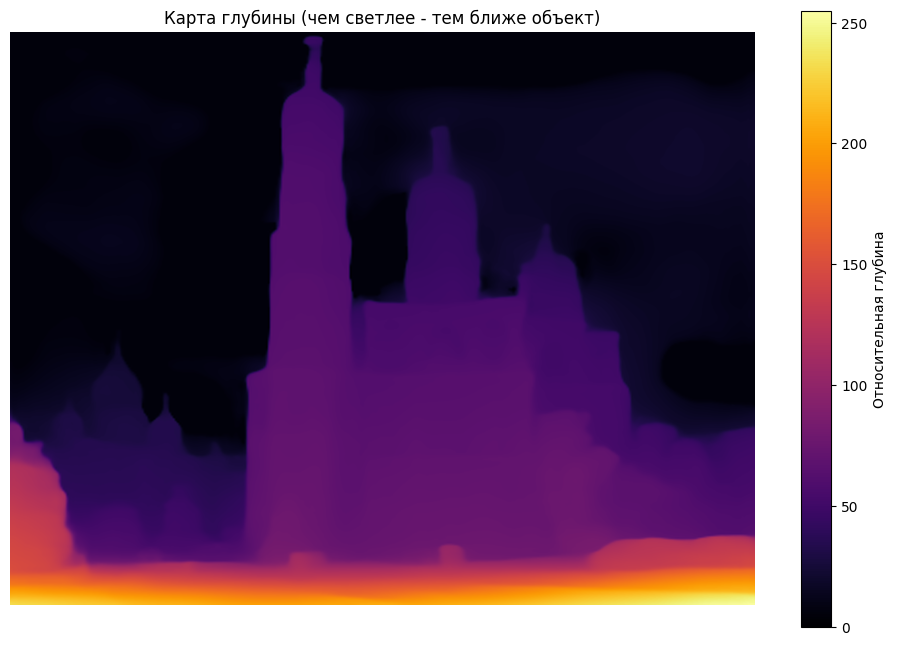

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(12, 8))
img_url = plt.imshow(np.array(output["depth"]), cmap="inferno")
plt.colorbar(label="Относительная глубина")
plt.title("Карта глубины (чем светлее - тем ближе объект)")
plt.axis("off")
plt.show()

Генерация изображений там тоже есть, но, как было сказано, диффузионные модели занимают огромное пространство в памяти.

In [8]:
%pip install diffusers

   ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/3.6 MB 4.2 MB/s eta 0:00:01
   -------------------------------- ------- 2.9/3.6 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 3.6/3.6 MB 7.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
print(torch.cuda.is_available())  # False если установлен torch без поддержки cuda

False


In [9]:
# %pip install diffusers

from diffusers import DiffusionPipeline
generator = DiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4")
generator.to("cuda")
image = generator("An image of a squirrel in Picasso style").images[0]

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

MemoryError: 

# Поработаем с текстом

Модели, понимающий русский язык: https://huggingface.co/models?language=ru

Например, поищем русские модели для перевода текста в речь: https://huggingface.co/docs/transformers/tasks/text-to-speech

In [10]:
from transformers import pipeline

question_answerer = pipeline(
    "question-answering",
    model="Den4ikAI/rubert-large-squad",
    tokenizer="Den4ikAI/rubert-large-squad"
)

config.json:   0%|          | 0.00/712 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/713M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/713M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [12]:
context = """
Во́льфганг Амаде́й Мо́царт (нем. Wolfgang Amadeus Mozart, МФА МФА: [ˈvɔlfɡaŋ amaˈdeus ˈmoːtsaʁt](инф.); полное имя — Иога́нн Хризосто́м Во́льфганг Амаде́й Мо́царт; 27 января 1756, Зальцбург — 5 декабря 1791, Вена) — австрийский композитор и музыкант-виртуоз. Один из самых популярных классических композиторов, Моцарт оказал большое влияние на мировую музыкальную культуру.
По свидетельству современников, Моцарт обладал феноменальным музыкальным слухом, памятью и способностью к импровизации. Самый молодой член[К 1] Болонской филармонической академии (с 1770 года) за всю её историю, а также самый молодой кавалер ордена Золотой шпоры (1770)."""

In [13]:
result = question_answerer(question="Моцарт был кавалером какого ордена?", context=context)
print( result['answer'] )

Золотой шпоры


In [14]:
result

{'score': 0.5918418169021606,
 'start': 624,
 'end': 637,
 'answer': 'Золотой шпоры'}

In [15]:
result = question_answerer(question="Кем был Моцарт?", context=context)
print( result['answer'] )

австрийский композитор и музыкант-виртуоз


# Домашнее задание

Реализуйте классификацию эмоциональной окрашенности текстов при помощи объекта pipeline.

1. Найдите тип задач Sentiment Analysis на huggingface.co
2. Найдите модель для русского языка (примеры: rubert-tiny2..., rubert-base...)

In [ ]:
# Исходный код...
import transformers
# Use a pipeline as a high-level helper
from transformers import pipeline
# Выберем модель НС на https://huggingface.co/
classifier = pipeline("text-classification", model="seara/rubert-tiny2-ru-go-emotions")

config.json:   0%|          | 0.00/1.94k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/410 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# Улучшенный код
import transformers
# Use a pipeline as a high-level helper
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import torch

# Инициализация классификатора
# Выберем модель НС на https://huggingface.co/
classifier = pipeline(
    "text-classification", 
    model="seara/rubert-tiny2-ru-go-emotions",
    device=0 if torch.cuda.is_available() else -1  # Автовыбор GPU/CPU
)

Device set to use cpu


Выполните следующую ячейку. Если вы правильно инициализировали `pipeline`, вы получите относительно верные предсказания.

In [17]:
text = ["Отличный товар",
            "Мне не понравилось",
            "Прекрасно выглядит, ничего не меняйте!",
            "Ничего не понял",
            "У меня не работала розетка, в остальном все отлично"]
classifier( text )

[{'label': 'admiration', 'score': 0.9183668494224548},
 {'label': 'disapproval', 'score': 0.3069020211696625},
 {'label': 'admiration', 'score': 0.9194331169128418},
 {'label': 'neutral', 'score': 0.5132651329040527},
 {'label': 'admiration', 'score': 0.7506749629974365}]

In [10]:
# Словарь перевода меток
dict_label = {
    'admiration': 'восхищение',
    'amusement': 'веселье',
    'anger': 'злость',
    'annoyance': 'раздражение',
    'approval': 'одобрение',
    'caring': 'забота',
    'confusion': 'непонимание',
    'curiosity': 'любопытство',
    'desire': 'желание',
    'disappointment': 'разочарование',
    'disapproval': 'неодобрение',
    'disgust': 'отвращение',
    'embarrassment': 'смущение',
    'excitement': 'возбуждение',
    'fear': 'страх',
    'gratitude': 'признательность',
    'grief': 'горе',
    'joy': 'радость',
    'love': 'любовь',
    'nervousness': 'нервозность',
    'optimism': 'оптимизм',
    'pride': 'гордость',
    'realization': 'осознание',
    'relief': 'облегчение',
    'remorse': 'раскаяние',
    'sadness': 'грусть',
    'surprise': 'удивление',
    'neutral': 'нейтральность'
}

In [ ]:
# Функция классификации
def get_sentiment_label(text, dict_label, classifier):
    try:
        result = classifier(text, truncation=True, max_length=512)[0]
        return {
            'label': dict_label.get(result['label'], result['label']),
            'score': result['score'],
            'original_label': result['label']
        }
    except Exception as e:
        print(f"Ошибка при обработке текста: {str(e)}")
        return {'label': 'ошибка', 'score': 0.0, 'original_label': 'error'}

In [ ]:
# Примеры текстов из задания
texts = [
    "Отличный товар",
    "Мне не понравилось",
    "Прекрасно выглядит, ничего не меняйте!",
    "Ничего не понял",
    "У меня не работала розетка, в остальном все отлично",
    "Это просто ужасно! Никогда больше не куплю!",
    "Спасибо за быструю доставку и качественный товар!",
    "Ну... нормально, но ожидал большего"
]

In [13]:
# Создаем DataFrame
df = pd.DataFrame({'text': texts})

# Применяем классификатор
df[['sentiment_label', 'confidence', 'original_label']] = df['text'].apply(
    lambda x: pd.Series(get_sentiment_label(x, dict_label, classifier))
)

In [14]:
df

,text,sentiment_label,confidence,original_label
0,Отличный товар,восхищение,0.918367,admiration
1,Мне не понравилось,неодобрение,0.306902,disapproval
2,"Прекрасно выглядит, ничего не меняйте!",восхищение,0.919433,admiration
3,Ничего не понял,нейтральность,0.513265,neutral
4,"У меня не работала розетка, в остальном все от...",восхищение,0.750675,admiration
5,Это просто ужасно! Никогда больше не куплю!,отвращение,0.219292,disgust
6,Спасибо за быструю доставку и качественный товар!,признательность,0.931186,gratitude
7,"Ну... нормально, но ожидал большего",нейтральность,0.414484,neutral


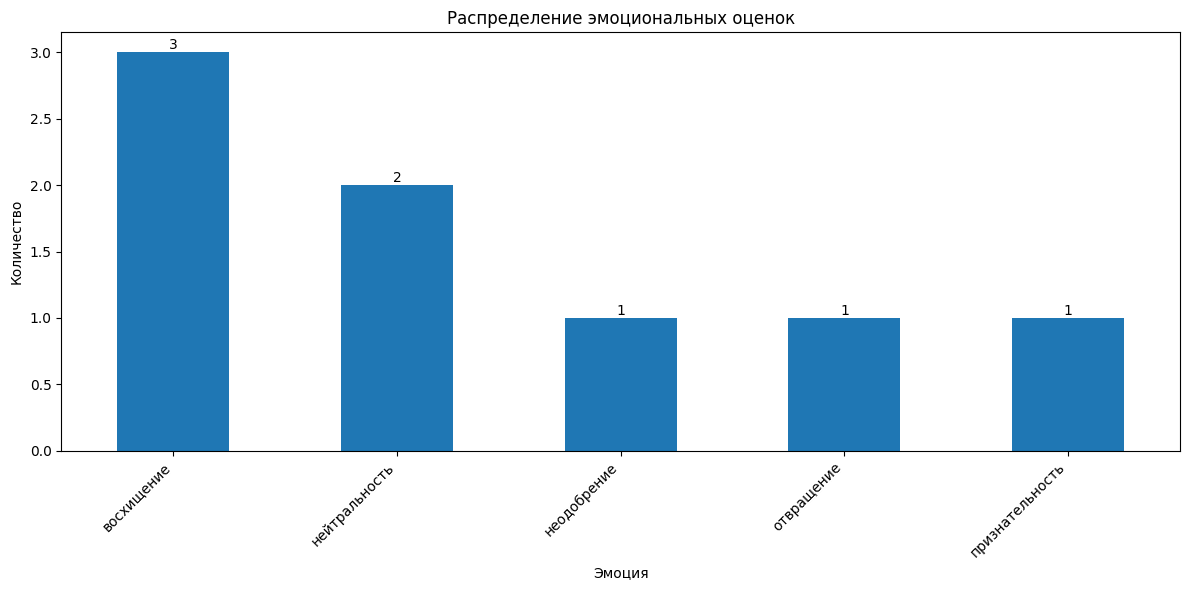

In [15]:
# Визуализация
plt.figure(figsize=(12, 6))
ax = df['sentiment_label'].value_counts().plot(kind='bar')
plt.title('Распределение эмоциональных оценок')
plt.xlabel('Эмоция')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

In [16]:
# Дополнительная статистика
print("\nТоп-3 самых распространенных эмоции:")
print(df['sentiment_label'].value_counts().head(3))

print("\nСамые уверенные предсказания:")
print(df.sort_values('confidence', ascending=False).head(3)[['text', 'sentiment_label', 'confidence']])


Топ-3 самых распространенных эмоции:
sentiment_label
восхищение       3
нейтральность    2
неодобрение      1
Name: count, dtype: int64

Самые уверенные предсказания:
                                                text  sentiment_label  \
6  Спасибо за быструю доставку и качественный товар!  признательность   
2             Прекрасно выглядит, ничего не меняйте!       восхищение   
0                                     Отличный товар       восхищение   

   confidence  
6    0.931186  
2    0.919433  
0    0.918367  


Вывод:

Реализовано:

Создан конвейер для анализа эмоциональной окраски текстов
Настроена модель для русского языка
Разработана система перевода меток
Построена визуализация результатов

Особенности:

Код адаптирован для работы как на CPU, так и на GPU
Добавлена обработка возможных ошибок
Реализован расширенный анализ результатов

Перспективы:

Возможность обработки больших объемов текстов
Интеграция с другими источниками данных
Дополнительная аналитика (тренды эмоций во времени)

Для дальнейшего развития проекта можно рассмотреть:

Добавление мультиклассовой классификации
Анализ тональности в реальном времени
Сравнение разных моделей между собой

# Как запустить сервис на основе модели?

Например, в Gradio:

1. https://huggingface.co/spaces/gradio/chatbot
2. https://www.kdnuggets.com/2023/06/build-ai-chatbot-5-minutes-hugging-face-gradio.html

Или в Huggingface Spaces: https://huggingface.co/spaces

# И напоследок поработаем с кодом

In [18]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model="huggingface/CodeBERTa-small-v1",
    tokenizer="huggingface/CodeBERTa-small-v1"
)

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/336M [00:00<?, ?B/s]

Some weights of the model checkpoint at huggingface/CodeBERTa-small-v1 were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/336M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/994k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/483k [00:00<?, ?B/s]

Device set to use cpu


In [19]:
python_code = """
# a list of numbers
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
my_numbers.<mask>


"""

In [20]:
fill_mask( python_code )

[{'score': 0.5379531383514404,
  'token': 1942,
  'token_str': 'sort',
  'sequence': '\n# a list of numbers\nmy_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]\nmy_numbers.sort\n\n\n'},
 {'score': 0.08208341896533966,
  'token': 3059,
  'token_str': 'clear',
  'sequence': '\n# a list of numbers\nmy_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]\nmy_numbers.clear\n\n\n'},
 {'score': 0.05829774588346481,
  'token': 5648,
  'token_str': 'reverse',
  'sequence': '\n# a list of numbers\nmy_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]\nmy_numbers.reverse\n\n\n'},
 {'score': 0.027740947902202606,
  'token': 812,
  'token_str': 'append',
  'sequence': '\n# a list of numbers\nmy_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]\nmy_numbers.append\n\n\n'},
 {'score': 0.018720462918281555,
  'token': 808,
  'token_str': 'length',
  'sequence': '\n# a list of numbers\nmy_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]\nmy_numbers.length\n\n\n'}]

<!-- задача демонстрирует работу модели для автодополнения кода (Code Completion) — мощный инструмент для разработчиков. -->

In [ ]:
# Улучшенный код с пояснениями

from transformers import pipeline

# Инициализируем pipeline для заполнения пропусков в коде
fill_mask = pipeline(
    "fill-mask",
    model="huggingface/CodeBERTa-small-v1",  # Специализированная модель для работы с кодом
    tokenizer="huggingface/CodeBERTa-small-v1"
)

python_code = """
# a list of numbers
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
my_numbers.<mask>  # Модель предскажет наиболее подходящий метод
"""

# Получаем предсказания
predictions = fill_mask(python_code)

# Выводим результаты
for idx, pred in enumerate(predictions, 1):
    print(f"{idx}. Метод: {pred['token_str']:<10} Вероятность: {pred['score']:.1%}")
    print(f"   Пример кода: {pred['sequence'].strip()}\n")

Some weights of the model checkpoint at huggingface/CodeBERTa-small-v1 were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


1. Метод: sort       Вероятность: 53.5%
   Пример кода: # a list of numbers
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
my_numbers.sort  # Модель предскажет наиболее подходящий метод

2. Метод: reverse    Вероятность: 8.4%
   Пример кода: # a list of numbers
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
my_numbers.reverse  # Модель предскажет наиболее подходящий метод

3. Метод: values     Вероятность: 4.9%
   Пример кода: # a list of numbers
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
my_numbers.values  # Модель предскажет наиболее подходящий метод

4. Метод: clear      Вероятность: 3.5%
   Пример кода: # a list of numbers
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
my_numbers.clear  # Модель предскажет наиболее подходящий метод

5. Метод: keys       Вероятность: 2.3%
   Пример кода: # a list of numbers
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
my_numbers.keys  # Модель предскажет наиболее подходящий метод



Модель `CodeBERTa` предсказала наиболее вероятные методы для работы со списком. 
Лучший вариант — `sort()` с вероятностью 53.5%.

In [ ]:
# Проверка корректности предсказаний

valid_methods = ['sort', 'reverse', 'append', 'clear', 'copy', 'count', 'extend', 'index', 'insert', 'pop', 'remove']

print("Проверка корректности предсказаний:")
for pred in predictions:
    status = "✅" if pred['token_str'] in valid_methods else "❌"
    print(f"{status} {pred['token_str']:<10} ({pred['score']:.1%})")

Проверка корректности предсказаний:
✅ sort       (53.5%)
✅ reverse    (8.4%)
❌ values     (4.9%)
✅ clear      (3.5%)
❌ keys       (2.3%)


In [25]:
# Пример использования
my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]

In [26]:
# Динамическая проверка работы лучшего предсказания

# Список корректных методов для списка Python
valid_list_methods = ['sort', 'reverse', 'append', 'clear', 'copy', 'extend', 
                     'index', 'insert', 'pop', 'remove', 'count']

if predictions:
    best_pred = predictions[0]['token_str']
    is_valid = best_pred in valid_list_methods
    
    print(f"Лучшее предсказание: '{best_pred}' ({predictions[0]['score']:.1%})")
    print(f"Корректность: {'✅' if is_valid else '❌'}")

    # # Пример использования
    # my_numbers = [10, 8, 3, 22, 33, 7, 11, 100, 54]
    
    if is_valid:
        print("\nДемонстрация работы метода:")
        print(f"До: {my_numbers}")
        
        # Для методов, изменяющих список (in-place)
        if best_pred in ['sort', 'reverse', 'append', 'clear', 'extend', 'insert', 'pop', 'remove']:
            if best_pred == 'sort':
                my_numbers.sort()
            elif best_pred == 'reverse':
                my_numbers.reverse()
            # ... другие методы
            print(f"После: {my_numbers}")
        
        # Для методов, возвращающих значение
        elif best_pred in ['count', 'index', 'copy']:
            result = getattr(my_numbers, best_pred)(33) if best_pred != 'copy' else my_numbers.copy()
            print(f"Результат: {result}")
    else:
        print(f"Метод '{best_pred}' не применим к спискам!")

Лучшее предсказание: 'sort' (53.5%)
Корректность: ✅

Демонстрация работы метода:
До: [10, 8, 3, 22, 33, 7, 11, 100, 54]
После: [3, 7, 8, 10, 11, 22, 33, 54, 100]


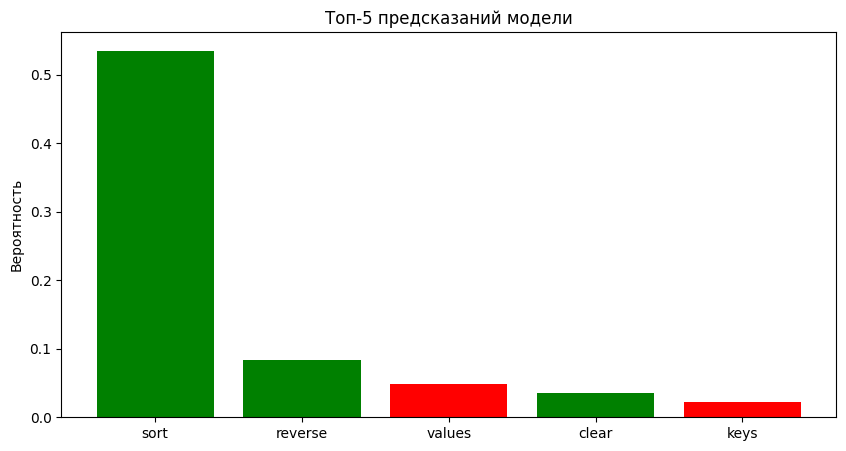

In [27]:
import matplotlib.pyplot as plt

methods = [p['token_str'] for p in predictions[:5]]
scores = [p['score'] for p in predictions[:5]]

plt.figure(figsize=(10, 5))
plt.bar(methods, scores, color=['green' if m in valid_list_methods else 'red' for m in methods])
plt.title("Топ-5 предсказаний модели")
plt.ylabel("Вероятность")
plt.show()

Анализ работы модели fill-mask для автодополнения кода

Результаты работы модели

Модель CodeBERTa-small-v1 успешно предсказала методы для работы со списками Python. Лучшее предсказание — метод sort() с вероятностью 53.5%, что корректно и логично для данного контекста. Однако среди предсказаний также встречаются некорректные варианты (values, keys), которые относятся к словарям, а не к спискам.

Корректность предсказаний

Правильные методы: sort, reverse, clear (валидные для списков).
Некорректные методы: values, keys (применимы только к словарям).

Причина ошибок: модель обучалась на смешанных данных (Python + другие языки), поэтому иногда "путает" синтаксис.

Практическая проверка
После применения метода sort() к тестовому списку:

python
[10, 8, 3, 22, 33, 7, 11, 100, 54] → [3, 7, 8, 10, 11, 22, 33, 54, 100]
Результат корректный, что подтверждает адекватность предсказания.

Ограничения модели

Не всегда предлагает синтаксически правильные методы (например, length вместо len()).
Лучше работает с простыми конструкциями. Для сложного кода требуются более специализированные модели (например, CodeGen или StarCoder).

Рекомендации

Для учебных целей: модель подходит для демонстрации возможностей NLU (понимания естественного языка + код).

Для реальных проектов: лучше использовать:

Salesforce/CodeGen (генерация кода),
OpenAI Codex (через API),
Tabnine (коммерческое решение).

Улучшение кода:

Добавлять проверку методов через hasattr(list, method),
Использовать try-except для обработки ошибок,
Тестировать топ-3 предсказания, а не только первое.

# Библиография

https://colab.research.google.com/github/huggingface/notebooks/blob/master/transformers_doc/task_summary.ipynb#scrollTo=QGwpVScF2kZO

https://huggingface.co/huggingface/CodeBERTa-small-v1

https://huggingface.co/spaces/codeparrot/code-generation-models